In [38]:
import os, pickle, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt
import shap
import time

# from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc

In [55]:
# Pandas 출력 옵션 조정 - All
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [57]:
# Pandas 출력 옵션 조정 - Default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

In [2]:
## Definitions

## Defines

# Data confirmmation :: Nan counts + Nan Ratios, Unique values
def analyse_dataframe(df):
    # NaN 개수, 비율 및 고유 값 개수 계산
    nan_counts = df.isnull().sum()
    nan_ratios = df.isnull().mean() * 100  # 백분율로 표시
    unique_values_count = df.nunique()

    # 결과 데이터 프레임 생성
    analysis_result = pd.DataFrame({
        'NaN Counts': nan_counts,
        'NaN Ratios (%)': nan_ratios,
        'Unique Values Count': unique_values_count
    })

    return analysis_result

def print_progress(iteration, total, prefix='', suffix='', decimals=1, length=50, fill='█', printEnd="\r"):
    """
    Call in a loop to create terminal progress bar
    @params:
        iteration   - Required  : current iteration (Int)
        total       - Required  : total iterations (Int)
        prefix      - Optional  : prefix string (Str)
        suffix      - Optional  : suffix string (Str)
        decimals    - Optional  : positive number of decimals in percent complete (Int)
        length      - Optional  : character length of bar (Int)
        fill        - Optional  : bar fill character (Str)
        printEnd    - Optional  : end character (e.g. "\r", "\r\n") (Str)
    """
    percent = ("{0:." + str(decimals) + "f}").format(100 * (iteration / float(total)))
    filledLength = int(length * iteration // total)
    bar = fill * filledLength + '-' * (length - filledLength)
    print(f'\r{prefix} |{bar}| {percent}% {suffix}', end=printEnd)
    # Print New Line on Complete
    if iteration == total: 
        print()

In [28]:
## Configs
SEED = 64

# base = '/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN'
base = '/media/bami/JHA/24-07_nedis/KNN'
out = f'{base}/Clustering/M15_dataset08/0531~/0711/WholeExp/survModel'
colmap = f'{base}/Clustering/M13'
# ipt = f'{base}/Dataset'
ipt = f'{base}/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA/PCA30/C8_Sil-Opt'

# out = f'{base}/Clustering/M01_Main'
# out = f'{base}/Clustering/M13/1_Whole'
# Z_dir = f'{base}/Clustering/M15_dataset08/0531~/0711/WholeExp/withPCA'

In [7]:
# Data import
# df = pd.read_csv(f"{ipt}/knn_prep-fin_M08.csv")
# df = pd.read_csv(f"{ipt}/knn_prep-fin_M08-alive.csv")
df = pd.read_csv(f'{ipt}/KNN_df_combined.csv')
df.rename(columns={'Unnamed: 0': 'idx_code'}, inplace=True)
df.set_index('idx_code', inplace=True)
print(len(df.columns))
df

163


Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.


,sex_sys_val,birthdt,bird,admd,apgs1,apgs5,bwei,mage,gran,parn,...,ntetoy_1,iperr_1,iperr_2,iperr_3,iperr_4,iperroy_1,iperroy_4,iperroy_3,iperroy_2,Cluster_Labels
idx_code,,,,,,,,,,,,,,,,,,,,,
0,1,2013-12-18,2013-12-18,2013-12-18,4.0,5.0,1350,29,1,0,...,0,1,0,0,0,1,0,0,0,4
1,1,2013-11-15,2013-11-15,2013-11-15,4.0,5.0,790,35,1,0,...,0,1,0,0,0,1,0,0,0,6
2,1,2013-11-15,2013-11-15,2013-11-15,5.0,6.0,1400,26,1,0,...,0,1,0,0,0,1,0,0,0,2
3,1,2013-11-15,2013-11-15,2013-11-15,6.0,7.0,1340,26,1,0,...,0,1,0,0,0,1,0,0,0,8
4,1,2013-11-11,2013-11-11,2013-11-11,4.0,5.0,1240,36,4,1,...,0,1,0,0,0,1,0,0,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20408,1,2022-11-28,2022-11-28,2022-11-28,5.0,8.0,1350,23,1,0,...,0,1,0,0,0,1,0,0,0,4
20409,1,2022-12-27,2022-12-27,2022-12-27,4.0,7.0,860,38,3,1,...,0,1,0,0,0,1,0,0,0,6
20410,0,2022-12-01,2022-12-01,2022-12-01,5.0,7.0,1910,30,2,0,...,0,1,0,0,0,1,0,0,0,4


In [8]:
# Drop cols
datetime_cols = [
    'ntetdt','ntetdty','date362','date36','menidt','pdaddth','pdaddt',
    'birthdt','admd','birtm','bird','efydt','death_dt','iperrdt'
]
rsndth_cols  = ['death_CR','death_NL','death_Inf','death_GI','death_CA','death_Otr']
drop_cols = ['ga'] + datetime_cols + rsndth_cols

target_keys = [
    'ntet_','ntety_','ntetoy_','SEPS_bef_NTET','SEPS_aft_NTET',
    'NTET_day','PDA_7d_NTET','invfpod','iperr_','iperroy_',
    'SEPS_bef_IPERR','SEPS_aft_IPERR','IPERR_day','PDA_7d_IPERR',
    'PDA_7d_IPERRorNTET','SEPS_bef_IPERRorNTET','SEPS_aft_IPERRorNTET',
    '7d_PDA','bdp','bdp_Moderate+','strdu_','inhg_','pvl_','nese_',
    'seps_3','pmirnsg_','pmirnsgnd','stday','oxyt36_','arre36_',
    'bwei','btem','bhei','bhead'
]
tgt_cols = [c for c in df.columns
            if c in target_keys or any(c.startswith(p) for p in target_keys)]

# Cluster label : 'Cluster_Labels'
cluster_col = 'Cluster_Labels' if 'Cluster_Labels' in df.columns else None
cluster_series = df[cluster_col].copy() if cluster_col else None

# Dataset : X, y --> Except 'Cluster_Labels'
extra_drop = ['Cluster_Labels'] if cluster_col else []
X = df.drop(columns=['death_label'] + tgt_cols + drop_cols + extra_drop, errors='ignore')
y = Surv.from_arrays(
    event=df['death_label'].astype(bool).values,
    time=df['stday'].astype(float).values
)


# Define column types
binary_cols = []
for c in X.columns:
    vals = pd.unique(X[c].dropna())
    if set(vals).issubset({0, 1}):
        binary_cols.append(c)
continuous_cols = [c for c in X.columns if c not in binary_cols]
print(f"[cols] Binary --> {len(binary_cols)}")
print(f"[cols] Continuous --> {len(continuous_cols)}")
print(f"[cols] Total --> {X.shape[1]}")


# Missing value processing
# X_filled = X.copy()
for col in continuous_cols:
    # 그룹별 평균 계산
    mean_surv = X.loc[df['death_label'] == 0, col].mean(skipna=True)
    mean_dead = X.loc[df['death_label'] == 1, col].mean(skipna=True)
    fill_value = np.nanmean([mean_surv, mean_dead])  # 두 값의 평균
    
    # NaN 채우기
    X[col] = X[col].fillna(fill_value)

X[col]

[cols] Binary --> 65
[cols] Continuous --> 13
[cols] Total --> 78


idx_code
0        10.000000
1        30.000000
2        14.000000
3        26.466243
4        31.000000
           ...    
20408    27.000000
20409    34.000000
20410     5.000000
20411     9.000000
20412     7.000000
Name: EFYN_day, Length: 20352, dtype: float64

In [34]:
## Train/Test split

In [51]:
# 1. Train-Test split

X_train_ov, X_test, y_train_ov, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
    , stratify=df['death_label']
)
print("Train set:", X_train_ov.shape)
print("Train label:", y_train_ov.shape)
print("Test set:", X_test.shape)
print("Test label:", y_test.shape)

# Save all dataset
with open(os.path.join(out, "datasets", "orn", "X_train_ov.pkl"), 'wb') as f:
    pickle.dump(X_train_ov, f)
with open(os.path.join(out, "datasets", "orn", "y_train_ov.pkl"), 'wb') as f:
    pickle.dump(y_train_ov, f)

with open(os.path.join(out, "datasets", "orn", "X_test.pkl"), 'wb') as f:
    pickle.dump(X_test, f)
with open(os.path.join(out, "datasets", "orn", "y_test.pkl"), 'wb') as f:
    pickle.dump(y_test, f)

Train set: (16281, 78)
Train label: (16281,)
Test set: (4071, 78)
Test label: (4071,)


In [52]:
# 2. Train-Validation split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_ov, y_train_ov, test_size=0.2, random_state=SEED
    , stratify=y_train_ov['event']
)
print("Train set:", X_train.shape)
print("Train label:", y_train.shape)
print("Validation set:", X_val.shape)
print("Validation label:", y_val.shape)

# Save all dataset
with open(os.path.join(out, "datasets", "orn", "X_train.pkl"), 'wb') as f:
    pickle.dump(X_train, f)
with open(os.path.join(out, "datasets", "orn", "y_train.pkl"), 'wb') as f:
    pickle.dump(y_train, f)

with open(os.path.join(out, "datasets", "orn", "X_val.pkl"), 'wb') as f:
    pickle.dump(X_val, f)
with open(os.path.join(out, "datasets", "orn", "y_val.pkl"), 'wb') as f:
    pickle.dump(y_val, f)

Train set: (13024, 78)
Train label: (13024,)
Validation set: (3257, 78)
Validation label: (3257,)


In [53]:
# 3. Scaler apply

# Define scaler
scaler = StandardScaler()

# apply scaler --> X_train
X_train_scd = X_train.copy()
X_train_scd[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])

# save scaler
os.makedirs(os.path.join(out, "models"), exist_ok=True)
with open(os.path.join(out, 'models', 'scaler_M01.pkl'), 'wb') as f:
    pickle.dump(scaler, f)


# load(used scaler)
with open(os.path.join(out, 'models', 'scaler_M01.pkl'), 'rb') as f:
    scaler_M01 = pickle.load(f)

# apply scaler --> X_val
X_val_scd  = X_val.copy()
X_val_scd[continuous_cols] = scaler_M01.transform(X_val[continuous_cols])

# apply scaler --> X_test
X_test_scd = X_test.copy()
X_test_scd[continuous_cols] = scaler_M01.transform(X_test[continuous_cols])


# Save scaled datasets
X_train_scd.to_csv(os.path.join(out, "datasets", "scd", "X_train_scd.csv"))
X_val_scd.to_csv(  os.path.join(out, "datasets", "scd", "X_val_scd.csv"))
X_test_scd.to_csv( os.path.join(out, "datasets", "scd", "X_test_scd.csv"))

# Save labels (y_*) --> as Surv structure
def dump_y(y_struct, name):
    y_df = pd.DataFrame({"event": y_struct["event"].astype(int),
                         "time":  y_struct["time"].astype(float)})
    y_df.to_csv(os.path.join(out, "datasets", "label", f"{name}.csv"), index=False)
dump_y(y_train, "y_train")
dump_y(y_val, "y_val")
dump_y(y_test, "y_test")

print("Scaling done. Files saved under:", {out})

Scaling done. Files saved under: {'/media/bami/d4960d77-e5f3-4877-a333-26e637be3a0e/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/survModel'}


In [56]:
analyse_dataframe(X_train_scd)

,NaN Counts,NaN Ratios (%),Unique Values Count
sex_sys_val,0,0.0,2
apgs1,0,0.0,12
apgs5,0,0.0,12
mage,0,0.0,40
gran,0,0.0,14
parn,0,0.0,10
bbph,0,0.0,110
bbphuk,0,0.0,2
bbbe,0,0.0,298
bbbeuk,0,0.0,2


In [59]:
for column in X_train_scd.columns:
    print(f"칼럼 이름: {column}")
    print(f"데이터 타입: {X_train_scd[column].dtype}")
    print(f"유니크한 값:")
    print(X_train_scd[column].unique())
    print("-" * 40)

칼럼 이름: sex_sys_val
데이터 타입: int64
유니크한 값:
[1 0]
----------------------------------------
칼럼 이름: apgs1
데이터 타입: float64
유니크한 값:
[ 1.06991149e+00 -3.61250117e-01 -1.79241173e+00  1.15803753e-01
 -8.38303988e-01  5.92857623e-01 -1.31535786e+00  1.54696536e+00
 -2.26946560e+00  2.02401923e+00 -2.16643961e-03  2.50107310e+00]
----------------------------------------
칼럼 이름: apgs5
데이터 타입: float64
유니크한 값:
[ 5.71093332e-01 -1.03512770e+00 -4.99720687e-01 -3.17675574e+00
  1.10650034e+00  3.56863227e-02 -1.57053471e+00 -3.71216275e+00
  1.64190735e+00 -2.10594172e+00 -2.64134873e+00 -3.20535542e-03]
----------------------------------------
칼럼 이름: mage
데이터 타입: float64
유니크한 값:
[-1.94109439  0.5936464   0.82407738 -2.17152537  0.36321542  1.97623228
 -0.32807752  0.13278444  1.28493934 -0.78893949 -0.55850851 -1.48023243
 -1.24980145  1.05450836  1.7458013  -0.09764654  1.51537032  2.20666326
 -1.01937047 -2.63238733 -2.86281831 -1.71066341 -2.40195635 -3.09324929
  2.43709425 -3.55411126  2.66752523

In [ ]:
## GRID SEARCH

In [58]:
# C-index scorer
def cindex_scorer(estimator, X, y):
    risk = estimator.predict(X)
    return concordance_index_censored(y["event"], y["time"], risk)[0]

# Base Model
rsf = RandomSurvivalForest(random_state=SEED, n_jobs=-1)

# Params
param_grid = {
    "n_estimators": [10, 25, 50, 100, 250]
    , "max_depth": [5, 10, 15, 20]
    , "max_features": [5, 10, 15, 20]
    , "min_samples_split" : [5, 10, 15, 20]
    , "min_samples_leaf" : [5, 10, 15, 20]
}

# GridSearchCV (5-fold CV)
grid = GridSearchCV(estimator=rsf
                    , param_grid=param_grid
                    , scoring=cindex_scorer   # C-index
                    , cv= KFold(n_splits=5, shuffle=True, random_state=SEED)
                    , n_jobs=-1
                    , refit=True
                    , verbose=1
                   )
grid.fit(X_train_scd, y_train)

# Results below -->
print("Best params:", grid.best_params_)
print("Best CV C-index (mean):", grid.best_score_)

# For best params
best_idx = grid.best_index_
mean_score = grid.cv_results_['mean_test_score'][best_idx]
std_score  = grid.cv_results_['std_test_score'][best_idx]
print(f"Best CV C-index: {mean_score:.4f} ± {std_score:.4f}")

best_rsf = grid.best_estimator_

Fitting 5 folds for each of 1280 candidates, totalling 6400 fits


/home/bami/anaconda3/envs/JHA_qiime2/lib/python3.8/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'max_depth': 5, 'max_features': 5, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best CV C-index (mean): 0.9773209544772998
Best CV C-index: 0.9773 ± 0.0033


In [ ]:
## Train-Validation process

Model saved. .
[Validation] C-index = 0.9774
[Test] C-index = 0.9774


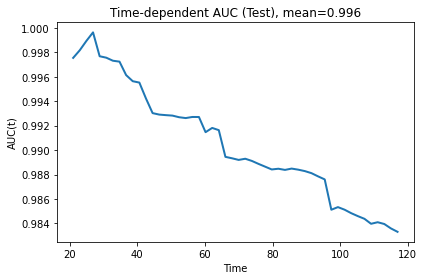

In [66]:
# optimal params
best_params = grid.best_params_

final_rsf = RandomSurvivalForest(**best_params
                                 , random_state=SEED
                                 , n_jobs=-1
                                )
final_rsf.fit(X_train_scd, y_train)

# Model save
with open(os.path.join(out, "models", "rsf_M01.pkl"), "wb") as f:
    pickle.dump(final_rsf, f)
print("Model saved. .")

# Evaluation --> X_val
risk_val = final_rsf.predict(X_val_scd)
c_val = concordance_index_censored(y_val["event"], y_val["time"], risk_val)[0]
print(f"[Validation] C-index = {c_val:.4f}")

# Evaluation --> X_test
risk_test = final_rsf.predict(X_test_scd)
c_test = concordance_index_censored(y_test["event"], y_test["time"], risk_test)[0]
print(f"[Test] C-index = {c_test:.4f}")

# Time-dependant AUC (AUC(t))
times = np.linspace(np.percentile(y_test["time"], 10),
                    np.percentile(y_test["time"], 90), 50)
auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_test, times)
plt.plot(times, auc, lw=2)
plt.xlabel("Time")
plt.ylabel("AUC(t)")
plt.title(f"Time-dependent AUC (Test), mean={mean_auc:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(out, "figs", "roc_time_auc_test.png"))
# plt.close()
plt.show()

In [ ]:
## Load dataset & Model

In [45]:
BASE_DIR = out
MODEL_PATH = os.path.join(BASE_DIR, "models", "rsf_M01.pkl")
ORN_DIR    = os.path.join(BASE_DIR, "datasets", "orn")
SCD_DIR    = os.path.join(BASE_DIR, "datasets", "scd")

with open(MODEL_PATH, "rb") as f:
    final_rsf = pickle.load(f)
print("[Loaded] Model -> final_rsf")

def _load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

X_train_ov = _load_pkl(os.path.join(ORN_DIR, "X_train_ov.pkl"))
y_train_ov = _load_pkl(os.path.join(ORN_DIR, "y_train_ov.pkl"))
X_test = _load_pkl(os.path.join(ORN_DIR, "X_test.pkl"))
y_test = _load_pkl(os.path.join(ORN_DIR, "y_test.pkl"))
X_train = _load_pkl(os.path.join(ORN_DIR, "X_train.pkl"))
y_train = _load_pkl(os.path.join(ORN_DIR, "y_train.pkl"))
X_val = _load_pkl(os.path.join(ORN_DIR, "X_val.pkl"))
y_val = _load_pkl(os.path.join(ORN_DIR, "y_val.pkl"))
print("[Loaded] ORN datasets -> X_train_ov, y_train_ov, X_test, y_test, X_train, y_train, X_val, y_val")

X_train_scd = pd.read_csv(os.path.join(SCD_DIR, "X_train_scd.csv"), index_col=0)
X_val_scd   = pd.read_csv(os.path.join(SCD_DIR, "X_val_scd.csv"),   index_col=0)
X_test_scd  = pd.read_csv(os.path.join(SCD_DIR, "X_test_scd.csv"),  index_col=0)
print("[Loaded] SCD datasets -> X_train_scd, X_val_scd, X_test_scd")

# Verify
def _shape(x):
    try:
        return x.shape
    except Exception:
        return type(x)
print("final_rsf type:", type(final_rsf))
print("X_train_ov / y_train_ov:", _shape(X_train_ov), _shape(y_train_ov))
print("X_train / y_train:", _shape(X_train), _shape(y_train))
print("X_val / y_val:", _shape(X_val), _shape(y_val))
print("X_test / y_test:", _shape(X_test), _shape(y_test))
print("SCD:", _shape(X_train_scd), _shape(X_val_scd), _shape(X_test_scd))

[Loaded] Model -> final_rsf
[Loaded] ORN datasets -> X_train_ov, y_train_ov, X_test, y_test, X_train, y_train, X_val, y_val
[Loaded] SCD datasets -> X_train_scd, X_val_scd, X_test_scd
final_rsf type: <class 'sksurv.ensemble.forest.RandomSurvivalForest'>
X_train_ov / y_train_ov: (16281, 78) (16281,)
X_train / y_train: (13024, 78) (13024,)
X_val / y_val: (3257, 78) (3257,)
X_test / y_test: (4071, 78) (4071,)
SCD: (13024, 78) (3257, 78) (4071, 78)


In [46]:
def _counts_pct(series):
    """0/1 시리즈에서 0,1의 건수와 비율(%)을 dict로 반환."""
    s = pd.to_numeric(pd.Series(series).dropna(), errors="coerce")
    s = s[s.isin([0,1])]
    total = len(s)
    c1 = int((s == 1).sum())
    c0 = int((s == 0).sum())
    pct1 = (c1 / total * 100) if total else 0.0
    pct0 = (c0 / total * 100) if total else 0.0
    return {
        "N": total,
        "Pos (n)": c1, "Pos (%)": round(pct1, 2),
        "Neg (n)": c0, "Neg (%)": round(pct0, 2)
    }

def _y_event_series(y):
    """
    y가 sksurv 구조배열(y['event'], y['time']) 또는
    pandas Series/DataFrame일 때 event 시리즈를 반환.
    """
    # sksurv structured array
    if isinstance(y, np.ndarray) and y.dtype.names is not None:
        if "event" in y.dtype.names:
            return pd.Series(y["event"].astype(int))
    # pandas DataFrame에 event 컬럼이 있는 경우
    if isinstance(y, pd.DataFrame):
        for cand in ["event", "death_label", "Event", "EVENT"]:
            if cand in y.columns:
                return pd.to_numeric(y[cand], errors="coerce")
    # pandas Series인 경우 0/1이라면 그대로
    if isinstance(y, pd.Series):
        return pd.to_numeric(y, errors="coerce")
    raise ValueError("y에서 event 정보를 찾을 수 없습니다.")

def summarize_datasets_outcomes(
    Xy_dict,
    nec_col="ntety_2",
    dataset_order=("Train", "Val", "Test", "Train_ov")
):
    """
    Xy_dict: {"Train": (X_train, y_train), "Val": (X_val, y_val), ...}
    nec_col: NEC 라벨이 들어있는 X의 컬럼명 (없으면 NEC 표는 건너뜀)
    """
    rows_death, rows_nec = [], []

    for name in dataset_order:
        if name not in Xy_dict:
            continue
        X, y = Xy_dict[name]

        # --- Death/Survival (y.event 기준) ---
        try:
            ev = _y_event_series(y)
            death_stats = _counts_pct(ev)
            rows_death.append({
                "Dataset": name,
                **death_stats
            })
        except Exception:
            # event 정보를 못 찾으면 스킵
            pass

        # --- NEC (X[nec_col] 기준) ---
        if isinstance(X, pd.DataFrame) and nec_col in X.columns:
            nec_stats = _counts_pct(X[nec_col])
            rows_nec.append({
                "Dataset": name,
                **nec_stats
            })

    tbl_death = pd.DataFrame(rows_death)[
        ["Dataset", "N", "Pos (n)", "Pos (%)", "Neg (n)", "Neg (%)"]
    ].rename(columns={
        "Pos (n)": "Death (n)", "Pos (%)": "Death (%)",
        "Neg (n)": "Survival (n)", "Neg (%)": "Survival (%)"
    }).reset_index(drop=True)

    tbl_nec = None
    if rows_nec:
        tbl_nec = pd.DataFrame(rows_nec)[
            ["Dataset", "N", "Pos (n)", "Pos (%)", "Neg (n)", "Neg (%)"]
        ].rename(columns={
            "Pos (n)": "NEC+ (n)", "Pos (%)": "NEC+ (%)",
            "Neg (n)": "NEC− (n)", "Neg (%)": "NEC− (%)"
        }).reset_index(drop=True)

    return tbl_death, tbl_nec

# 이미 로드된 변수들: X_train, y_train, X_val, y_val, X_test, y_test,
# 선택적으로 X_train_ov, y_train_ov
Xy = {
    "Train":   (X_train, y_train),
    "Val":     (X_val,   y_val),
    "Test":    (X_test,  y_test),
}

death_table, nec_table = summarize_datasets_outcomes(
    Xy_dict=Xy,
    nec_col="ntety_2",
    dataset_order=("Train", "Val", "Test", "Train_ov")
)

print("=== Death / Survival ===")
print(death_table.to_string(index=False))

if nec_table is not None:
    print("\n=== NEC Positive / Negative ===")
    print(nec_table.to_string(index=False))
else:
    print("\n(NEC 표시는 생략됨: nec_col이 존재하지 않거나 어느 X에도 없습니다.)")

=== Death / Survival ===
Dataset     N  Death (n)  Death (%)  Survival (n)  Survival (%)
  Train 13024       1658      12.73         11366         87.27
    Val  3257        415      12.74          2842         87.26
   Test  4071        518      12.72          3553         87.28

(NEC 표시는 생략됨: nec_col이 존재하지 않거나 어느 X에도 없습니다.)


In [ ]:
# Plots

In [22]:
def plot_cluster_survival(model, X, clusters, title, save_path,
                          figsize=(12, 7), dpi=150):
    """클러스터별 평균 생존함수 플롯 → PDF 저장, 범례는 아래 한 줄."""
    surv_funcs = model.predict_survival_function(X)

    # 고유 클러스터 정렬
    uniq = sorted(pd.unique(clusters.dropna()))

    # Figure/Axes
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # 각 클러스터 평균 생존함수
    for cl in uniq:
        mask = (clusters == cl).values
        if mask.sum() == 0:
            continue
        funcs = [surv_funcs[i] for i, keep in enumerate(mask) if keep]
        ts = np.unique(np.concatenate([fn.x for fn in funcs]))
        mat = np.vstack([fn(ts) for fn in funcs])
        mean_surv = mat.mean(axis=0)
        ax.step(ts, mean_surv, where="post", label=f"Cluster {cl}")

    ax.set_xlabel("Time", fontsize=11)
    ax.set_ylabel("Survival probability", fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13)

    # 범례를 아래 1줄로
    ncol = max(1, len(uniq))
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),   # ← 이전 -0.15 에서 ↑ 가까이
        ncol=ncol,
        frameon=True,
        fontsize=10,
        handlelength=1.8,
        columnspacing=1.0,
        borderpad=0.6,
        handletextpad=0.6
    )
    fig.subplots_adjust(bottom=0.15)

    # === PDF 저장 (os.path만 사용) ===
    # 확장자 강제로 .pdf
    base, ext = os.path.splitext(save_path)
    pdf_path = base + ".pdf"
    # 디렉토리 생성
    os.makedirs(os.path.dirname(pdf_path), exist_ok=True)
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")

    plt.show()

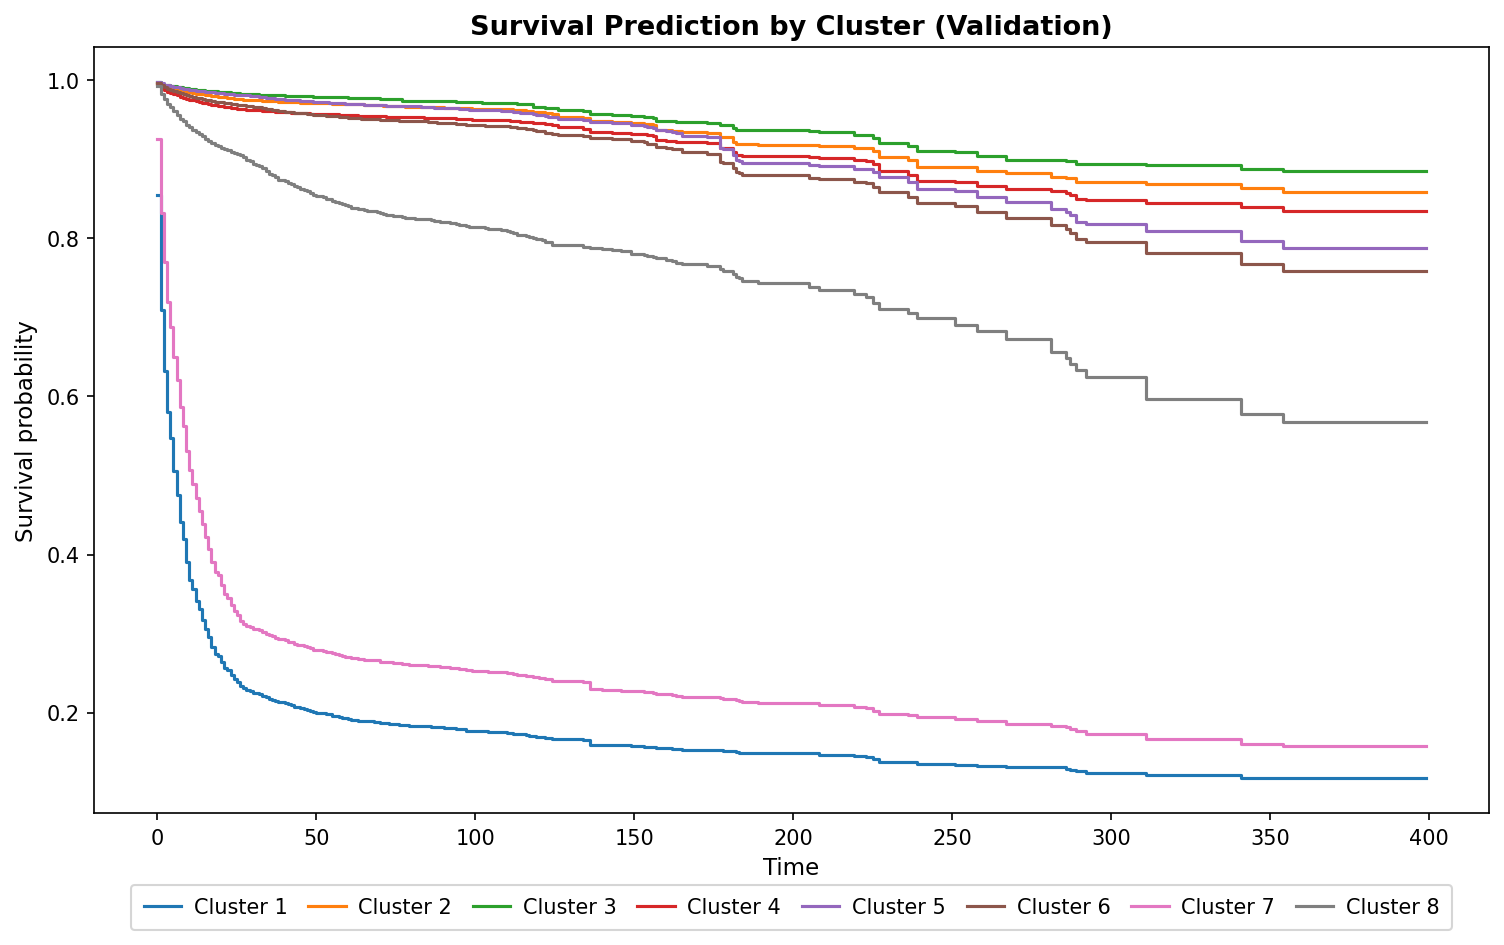

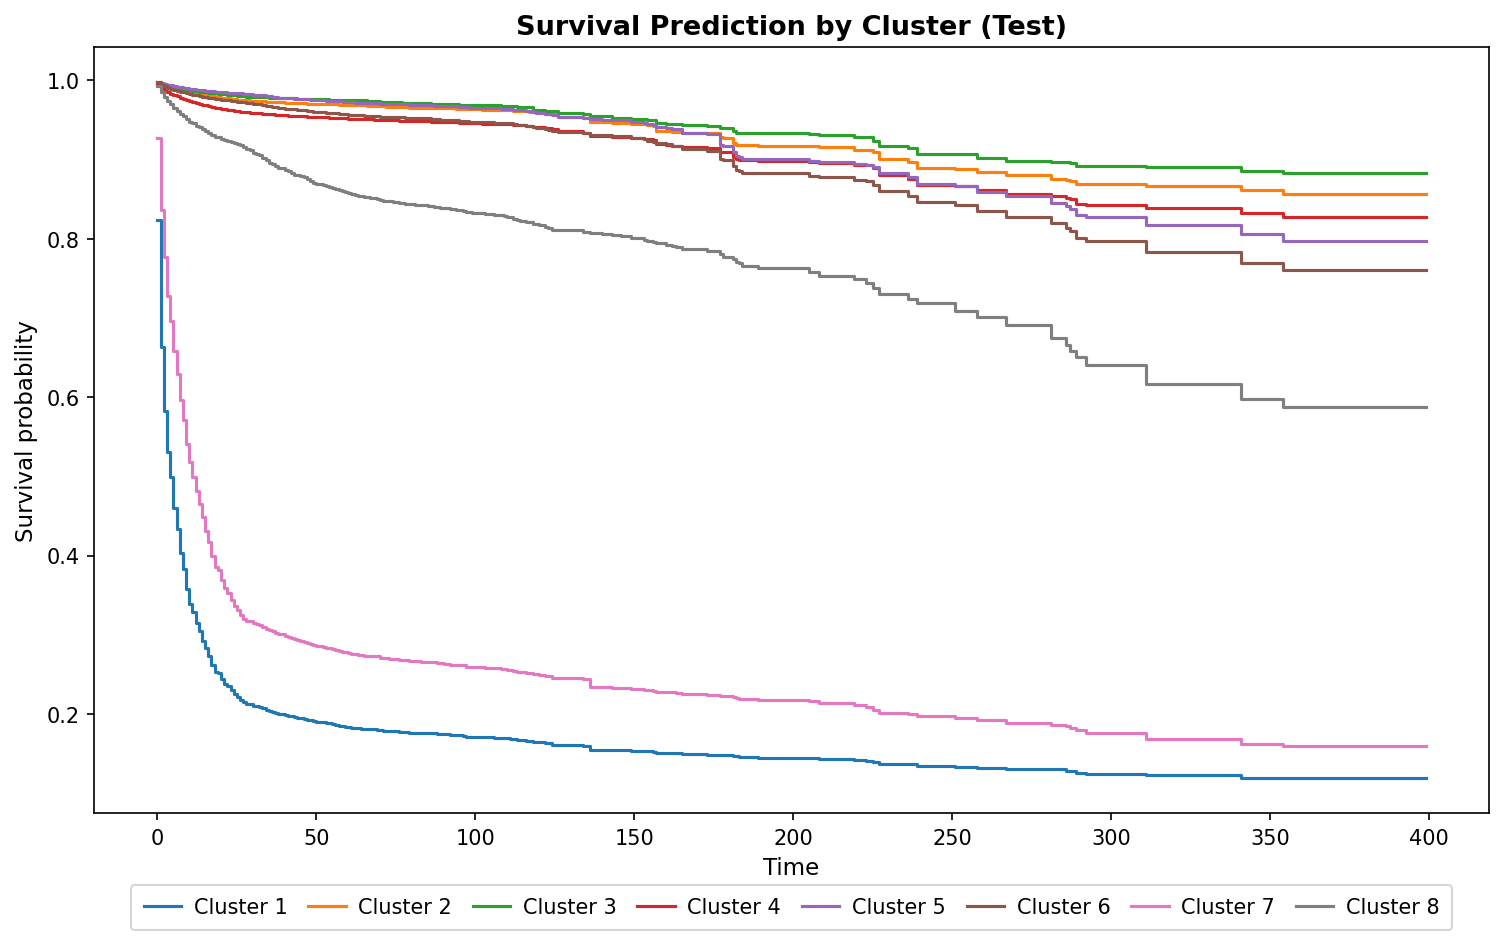

In [23]:
# Validation clusters
if cluster_series is not None:
    plot_cluster_survival(
        final_rsf,
        X_val_scd,
        cluster_series.loc[X_val.index],
        "Survival Prediction by Cluster (Validation)",
        os.path.join(out, "figs", "survival_by_cluster_val.pdf")
    )

# Test clusters
if cluster_series is not None:
    plot_cluster_survival(
        final_rsf,
        X_test_scd,
        cluster_series.loc[X_test.index],
        "Survival Prediction by Cluster (Test)",
        os.path.join(out, "figs", "survival_by_cluster_test.pdf")
    )

In [47]:
def build_feature_name_mapper(df_dic: pd.DataFrame,
                              key_col: str = "col_name",
                              feat_col: str = "feature_name") -> dict:
    """df_dic[key_col] → df_dic[feat_col] 매핑 딕셔너리 생성."""
    dic = df_dic[[key_col, feat_col]].dropna(subset=[key_col]).copy()
    dic[key_col]  = dic[key_col].astype(str).str.strip()
    dic[feat_col] = dic[feat_col].astype(str).str.strip()
    return dic.set_index(key_col)[feat_col].to_dict()

def apply_feature_name_mapper(X: pd.DataFrame,
                              mapper: dict,
                              drop_sum_other: bool = True,
                              make_unique: bool = True) -> pd.DataFrame:
    """
    - (선택) 'Sum of Other features' 컬럼 제거
    - mapper에 따라 컬럼명만 변경(매핑 없으면 원래 이름 유지)
    - (선택) 매핑으로 중복 이름 생기면 유니크하게 후처리
    """
    if not isinstance(X, pd.DataFrame):
        raise TypeError("X는 pandas.DataFrame이어야 합니다.")

    X2 = X.copy()
    if drop_sum_other and "Sum of Other features" in X2.columns:
        X2 = X2.drop(columns=["Sum of Other features"])

    # rename (매핑 없는 건 그대로)
    X2 = X2.rename(columns=lambda c: mapper.get(str(c), str(c)))

    if make_unique and len(set(X2.columns)) != len(X2.columns):
        seen, out = {}, []
        for c in X2.columns:
            if c not in seen:
                seen[c] = 1
                out.append(c)
            else:
                out.append(f"{c}__{seen[c]}")  # 뒤에 번호 붙이기
                seen[c] += 1
        X2.columns = out

    return X2

df_dic = pd.read_excel(os.path.join(colmap, "list_4_sort(features_EN).xlsx"))[
    ["col_name","feature_name"]
]
name_mapper = build_feature_name_mapper(df_dic)

In [49]:
def plot_shap_beeswarm_pdf_for_rsf(
    model,
    X_orig: pd.DataFrame,
    display_name_mapper: dict = None,
    top_n: int = 20,
    save_path: str = "shap_beeswarm.pdf",
    background_size: int = 200,
    random_state: int = 42,
    figsize=(12, 8),
    drop_from_plot: set = None,
    verbose: bool = True,
    show_progress: bool = True,
    title: str = None,
    title_fontsize: int = 14,
    title_pad: int = 16,
):
    t0 = time.perf_counter()
    def log(msg):
        if verbose:
            print(f"[SHAP] {msg}")

    if not isinstance(X_orig, pd.DataFrame):
        raise TypeError("X_orig는 pandas.DataFrame이어야 합니다.")

    log("Start")
    rng = np.random.default_rng(random_state)
    if len(X_orig) > background_size:
        bg_idx = rng.choice(len(X_orig), size=background_size, replace=False)
        X_bg = X_orig.iloc[bg_idx].copy()
        log(f"Background sampled: {len(X_bg)}/{len(X_orig)}")
    else:
        X_bg = X_orig.copy()
        log(f"Background uses full data: {len(X_bg)}")

    def predict_risk(x_array):
        df_in = pd.DataFrame(x_array, columns=X_orig.columns)
        return model.predict(df_in)

    log("Building explainer…")
    explainer = shap.Explainer(predict_risk, X_bg, seed=random_state)
    log("Computing SHAP values…")
    sv = explainer(X_orig, silent=not show_progress)

    # 표시 이름
    if display_name_mapper is None:
        display_names = list(X_orig.columns)
    else:
        display_names = [display_name_mapper.get(str(c), str(c)) for c in X_orig.columns]

    # 제외 목록(표시 이름 기준)
    keep_idx = list(range(len(display_names)))
    if drop_from_plot:
        drop_from_plot = set(drop_from_plot)
        keep_idx = [i for i, nm in enumerate(display_names) if nm not in drop_from_plot]

    # 상위 n개만 선택 → “Sum of other” 제거
    mean_abs = np.abs(sv.values).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    order = [i for i in order if i in keep_idx]
    sel_idx = order[:int(top_n)]
    sel_names = [display_names[i] for i in sel_idx]

    sv_disp = sv[:, sel_idx]
    sv_disp.feature_names = sel_names

    # 플롯
    plt.figure(figsize=figsize)
    shap.plots.beeswarm(sv_disp, max_display=len(sel_idx), show=False)
    if title:
        plt.title(title, fontsize=title_fontsize, pad=title_pad)  # ★ pad 적용

    # 저장
    base, _ = os.path.splitext(save_path)
    pdf_path = base + ".pdf"
    os.makedirs(os.path.dirname(pdf_path) or ".", exist_ok=True)

    # 타이틀이 안 잘리게 하면서도 간격 유지: top을 살짝만 남겨둠
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
    plt.show()

    log(f"Saved PDF → {pdf_path}")
    log(f"Done in {time.perf_counter()-t0:.2f}s")
    return {"pdf_path": pdf_path, "shap_values": sv_disp, "explainer": explainer}

[SHAP] Start
[SHAP] Background sampled: 200/4071
[SHAP] Building explainer…
[SHAP] Computing SHAP values…


PermutationExplainer explainer: 4072it [26:54,  2.51it/s]                          


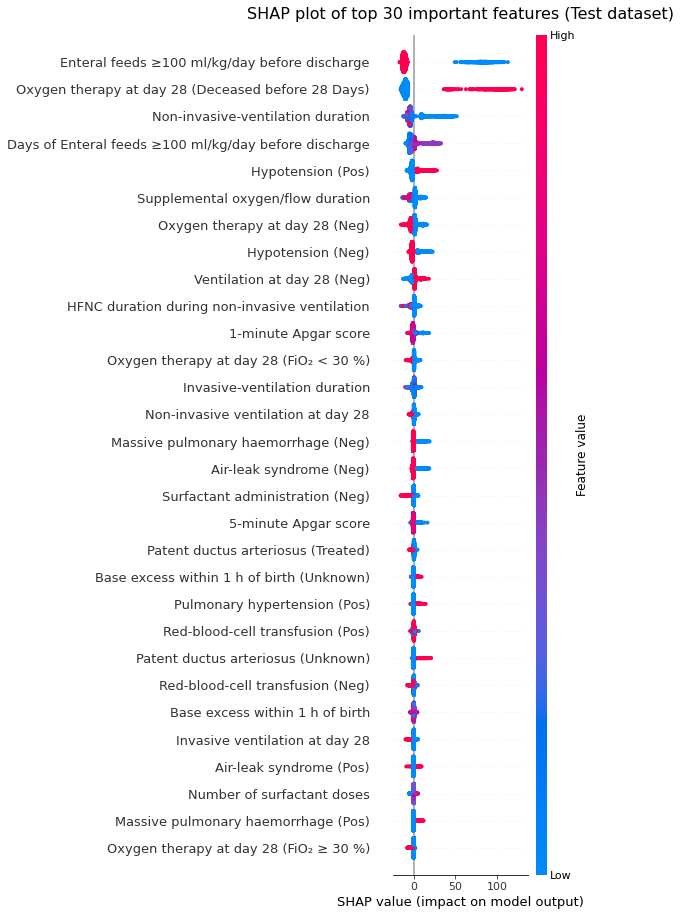

[SHAP] Saved PDF → /media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/survModel/figs/shap_beeswarm_test.pdf
[SHAP] Done in 1617.12s
[SHAP] Start
[SHAP] Background sampled: 200/3257
[SHAP] Building explainer…
[SHAP] Computing SHAP values…


PermutationExplainer explainer: 3258it [21:30,  2.50it/s]                          


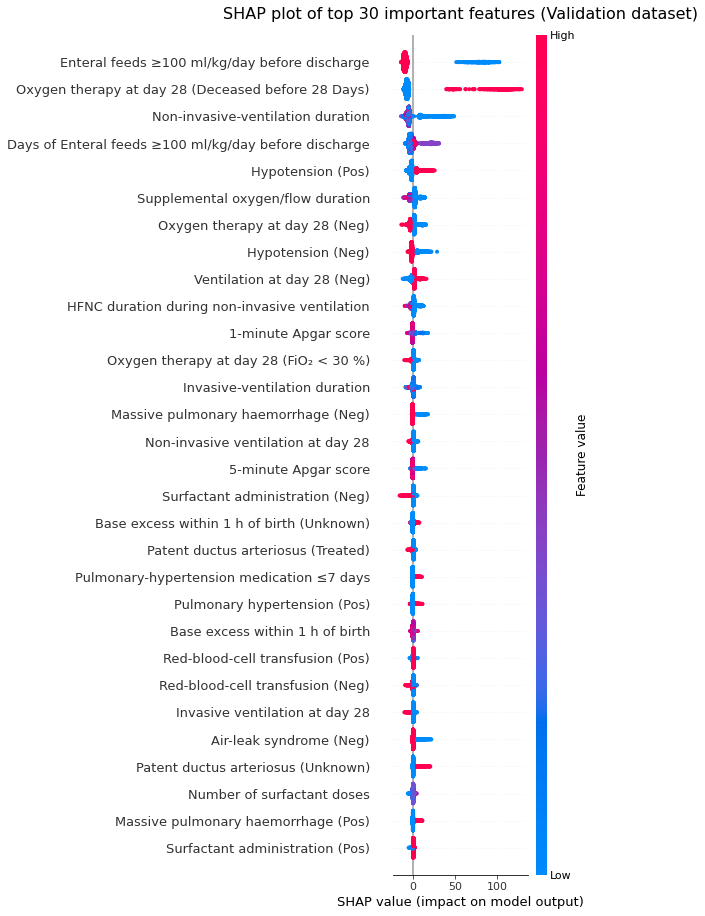

[SHAP] Saved PDF → /media/bami/JHA/24-07_nedis/KNN/Clustering/M15_dataset08/0531~/0711/WholeExp/survModel/figs/shap_beeswarm_val.pdf
[SHAP] Done in 1292.04s


In [51]:
feat_n = 30
drop_set = {"Sum of Other features"}

# Apply to Test set
res_test = plot_shap_beeswarm_pdf_for_rsf(
    model=final_rsf,
    X_orig=X_test_scd,
    display_name_mapper=name_mapper,
    top_n=feat_n,
    save_path=os.path.join(out, "figs", "shap_beeswarm_test.pdf"),
    figsize=(14, 12),
    drop_from_plot=drop_set,
    title=f"SHAP plot of top {feat_n} important features (Test dataset)",
    title_fontsize=16,
    title_pad=16
)

# Apply to Validation set
res_val = plot_shap_beeswarm_pdf_for_rsf(
    model=final_rsf,
    X_orig=X_val_scd,
    display_name_mapper=name_mapper,
    top_n=feat_n,
    save_path=os.path.join(out, "figs", "shap_beeswarm_val.pdf"),
    figsize=(14, 12),
    drop_from_plot=drop_set,
    title=f"SHAP plot of top {feat_n} important features (Validation dataset)",
    title_fontsize=16,
    title_pad=16
)

PermutationExplainer explainer: 4072it [26:19,  2.57it/s]                          


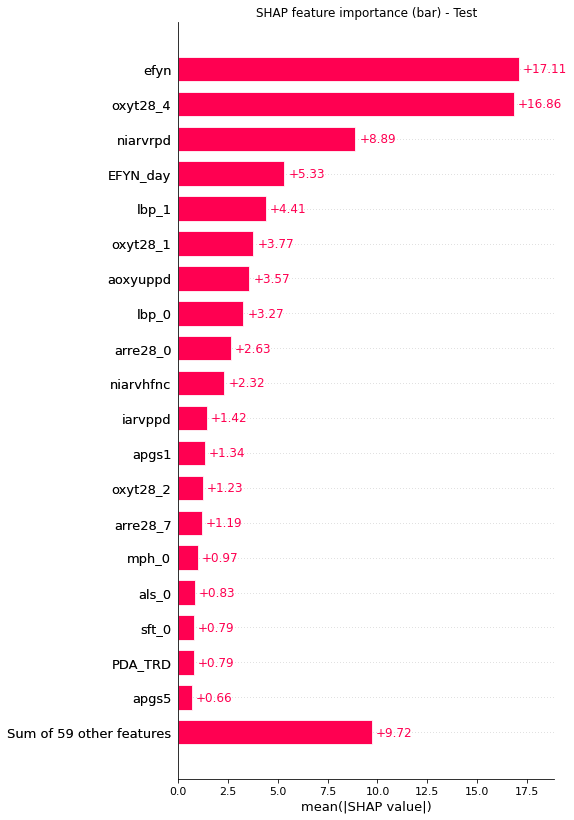

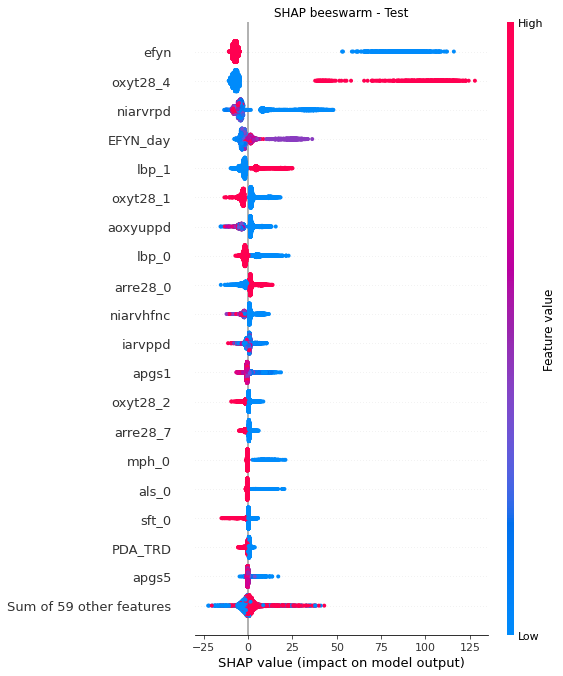

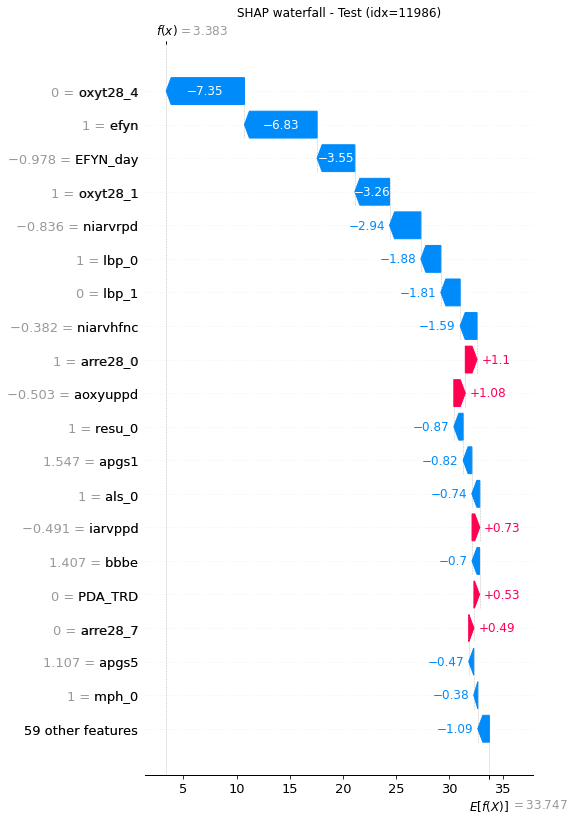

In [71]:
## SHAP value plotting

model_path = os.path.join(out, "models", "rsf_M01.pkl")
fig_dir    = os.path.join(out, "figures")

# SAVE
with open(model_path, "rb") as f:
    rsf = pickle.load(f)

# data
bg_size = min(200, len(X_train_scd))
background = X_train_scd.sample(n=bg_size, random_state=SEED)

# Compose 'Explainer'
explainer = shap.Explainer(lambda X: rsf.predict(X), background)

# calc SHAP values
shap_values_test = explainer(X_test_scd)

# (A) Bar plot (상위 20개)
plt.figure()
shap.plots.bar(shap_values_test, max_display=30, show=False)
plt.title("SHAP feature importance (bar) - Test")
plt.tight_layout()
# plt.savefig(os.path.join(fig_dir, "shap_bar_test.png"), dpi=150)
plt.show()

# (B) Beeswarm (상위 20개, 값의 분포)
plt.figure()
shap.plots.beeswarm(shap_values_test, max_display=30, show=False)
plt.title("SHAP beeswarm - Test")
plt.tight_layout()
# plt.savefig(os.path.join(fig_dir, "shap_beeswarm_test.png"), dpi=150)
plt.show()

# (C) 개별 샘플 Waterfall (임의 index 하나 선택)
sample_idx = X_test_scd.index[0]
shap_single = shap_values_test[X_test_scd.index.get_loc(sample_idx)]
plt.figure()
shap.plots.waterfall(shap_single, max_display=30, show=False)
plt.title(f"SHAP waterfall - Test (idx={sample_idx})")
plt.tight_layout()
# plt.savefig(os.path.join(fig_dir, f"shap_waterfall_test_idx{sample_idx}.png"), dpi=150)
plt.show()

In [ ]:
fig_dir  = os.path.join(out, "figs"); os.makedirs(fig_dir, exist_ok=True)
tab_dir  = os.path.join(out, "tables");  os.makedirs(tab_dir, exist_ok=True)


# 1) Impurity-based (MDI) importance
fi = pd.Series(final_rsf.feature_importances_, index=X_train_scd.columns)
fi = fi.sort_values(ascending=False)

# SAVE
fi.to_csv(os.path.join(tab_dir, "feature_importance_mdi.csv"))

# Plotting
topN = 30
plt.figure(figsize=(7, max(3, topN*0.3)))
fi.head(topN).iloc[::-1].plot(kind="barh")
plt.xlabel("MDI importance")
plt.title(f"RSF Feature Importance (MDI) - Top {topN}")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, f"feat_importance_mdi_top{topN}.png"), dpi=150)
plt.close()

print("[MDI] saved:",
      os.path.join(tab_dir, "feature_importance_mdi.csv"),
      os.path.join(fig_dir, f"feat_importance_mdi_top{topN}.png"))

# 2) Permutation importance (C-index 기반)
#    - Validation 세트 기준 권장

# Grid/평가 때 썼던 C-index scorer 재사용
def cindex_scorer(estimator, X, y):
    from sksurv.metrics import concordance_index_censored
    risk = estimator.predict(X)
    return concordance_index_censored(y["event"], y["time"], risk)[0]

perm = permutation_importance(
    final_rsf,
    X_val_scd,
    y_val,
    n_repeats=30,
    random_state=SEED,
    scoring=cindex_scorer,
    n_jobs=-1
)

pi_mean = pd.Series(perm.importances_mean, index=X_val_scd.columns)
pi_std  = pd.Series(perm.importances_std,  index=X_val_scd.columns)
pi = pd.DataFrame({"perm_importance_mean": pi_mean, "perm_importance_std": pi_std})
pi = pi.sort_values("perm_importance_mean", ascending=False)

# 저장
pi.to_csv(os.path.join(tab_dir, "feature_importance_permutation_val.csv"))

# 플롯 (Top 20)
plt.figure(figsize=(7, max(3, topN*0.3)))
pi.head(topN).iloc[::-1]["perm_importance_mean"].plot(kind="barh")
plt.xlabel("Permutation importance (Δ C-index)")
plt.title(f"RSF Permutation Importance (Validation) - Top {topN}")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, f"feat_importance_perm_val_top{topN}.png"), dpi=150)
plt.close()